# NVDA sentiment correlation analysis 

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from scipy.stats import pearsonr

Load News Dataset

In [2]:
news_df = pd.read_csv(
    '../data/raw/newsData/raw_analyst_ratings.csv'
)

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


Date Preparation

In [3]:
news_df['date'] = pd.to_datetime(
    news_df['date'],
    format='mixed',
    utc=True
)

news_df['date_only'] = (
    news_df['date']
    .dt.tz_localize(None)
    .dt.date
)

# Sentiment Analysis

## Sentiment Analysis Function

In [4]:
def get_sentiment(text):

    return TextBlob(
        str(text)
    ).sentiment.polarity

## Compute Sentiment Scores

In [5]:
news_df['sentiment_score'] = (
    news_df['headline']
    .apply(get_sentiment)
)

## Sentiment Classification Function

In [6]:
def sentiment_label(score):

    if score > 0:
        return 'Positive'

    elif score < 0:
        return 'Negative'

    else:
        return 'Neutral'

### Apply Sentiment Labels

In [7]:
news_df['sentiment_label'] = (
    news_df['sentiment_score']
    .apply(sentiment_label)
)

Select Company

In [8]:
company = 'NVDA'

### Filter News for Company

In [9]:
company_news = news_df[
    news_df['stock'] == company
].copy()

## Aggregate Daily Sentiment

In [10]:
daily_sentiment = (
    company_news
    .groupby('date_only')
    .agg({
        'sentiment_score': 'mean'
    })
    .reset_index()
)

## Classify Daily Sentiment 

In [11]:
daily_sentiment['sentiment_category'] = (
    daily_sentiment['sentiment_score']
    .apply(sentiment_label)
)

Load Stock Dataset

In [12]:
stock_df = pd.read_csv(
    f'../data/raw/yfinance_data/Data/{company}.csv'
)

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


## Prepare Stock Dates

In [13]:
stock_df['Date'] = pd.to_datetime(
    stock_df['Date']
)

stock_df['date_only'] = (
    stock_df['Date']
    .dt.date
)

## Compute Daily Returns

In [14]:
stock_df['Daily_Return'] = (
    (
        stock_df['Close']
        - stock_df['Close'].shift(1)
    )
    /
    stock_df['Close'].shift(1)
) * 100

## Align Weekend/Holiday News

In [15]:
trading_days = stock_df['date_only'].tolist()

def align_to_trading_day(news_date):

    while news_date not in trading_days:

        news_date = (
            pd.Timestamp(news_date)
            + pd.Timedelta(days=1)
        ).date()

    return news_date

In [16]:
daily_sentiment['aligned_date'] = (
    daily_sentiment['date_only']
    .apply(align_to_trading_day)
)

### Merge Datasets

In [17]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df,
    left_on='aligned_date',
    right_on='date_only',
    how='inner'
)

merged_df.head()

,date_only_x,sentiment_score,sentiment_category,aligned_date,Date,Close,High,Low,Open,Volume,date_only_y,Daily_Return
0,2011-03-03,-0.300,Negative,2011-03-03,2011-03-03,0.478385,0.489388,0.463944,0.486637,1593704000,2011-03-03,0.578321
1,2011-03-07,-0.125,Negative,2011-03-07,2011-03-07,0.469216,0.480907,0.457297,0.479302,1019140000,2011-03-07,-1.396890
2,2011-03-08,0.000,Neutral,2011-03-08,2011-03-08,0.448128,0.476780,0.438271,0.474259,1947184000,2011-03-08,-4.494412
3,2011-03-09,0.000,Neutral,2011-03-09,2011-03-09,0.438730,0.451108,0.434833,0.446752,1318976000,2011-03-09,-2.097166
4,2011-03-10,0.500,Positive,2011-03-10,2011-03-10,0.410765,0.431853,0.410306,0.428644,1722736000,2011-03-10,-6.374086


# Pearson Correlation

In [18]:
correlation, p_value = pearsonr(
    merged_df['sentiment_score'],
    merged_df['Daily_Return']
)

print(f'Pearson Correlation: {correlation}')

print(f'P-value: {p_value}')

Pearson Correlation: 0.08654504145667294
P-value: 0.002728706866286471


### Scatter Plot with Correlation Annotation

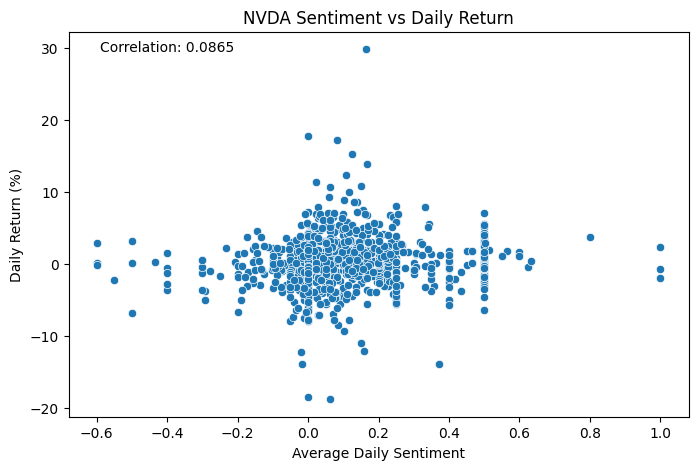

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='sentiment_score',
    y='Daily_Return',
    data=merged_df
)

plt.title(
    f'{company} Sentiment vs Daily Return'
)

plt.xlabel('Average Daily Sentiment')

plt.ylabel('Daily Return (%)')

plt.annotate(
    f'Correlation: {correlation:.4f}',
    xy=(0.05, 0.95),
    xycoords='axes fraction'
)

plt.show()

### Average Return by Sentiment Category

In [20]:
category_returns = (
    merged_df
    .groupby('sentiment_category')['Daily_Return']
    .mean()
    .reset_index()
)

category_returns

,sentiment_category,Daily_Return
0,Negative,-0.657427
1,Neutral,-0.047987
2,Positive,0.747871


## Bar Chart

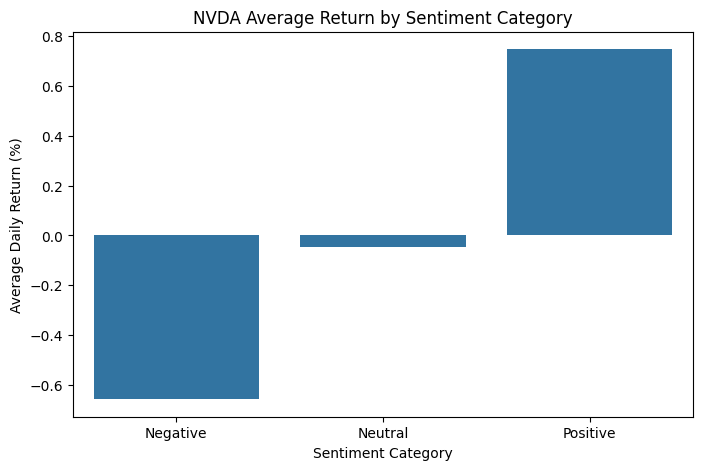

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='sentiment_category',
    y='Daily_Return',
    data=category_returns
)

plt.title(
    f'{company} Average Return by Sentiment Category'
)

plt.xlabel('Sentiment Category')

plt.ylabel('Average Daily Return (%)')

plt.show()

## Sentiment Distribution Visualization

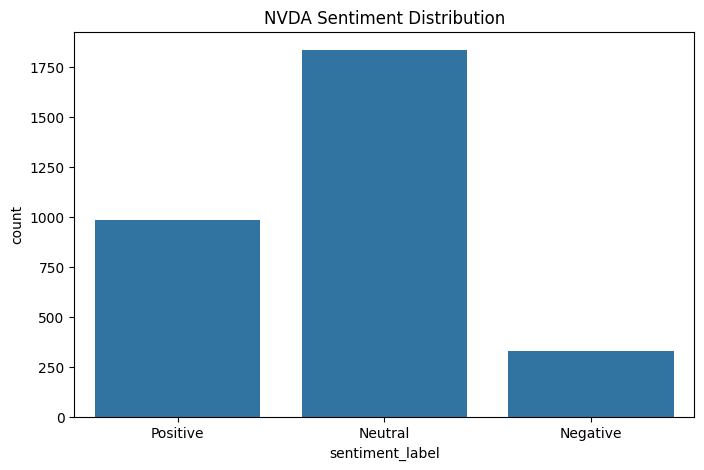

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='sentiment_label',
    data=company_news
)

plt.title(
    f'{company} Sentiment Distribution'
)

plt.show()

## Interpretation of Results

The sentiment analysis revealed a mixture of positive, neutral, and negative financial news headlines associated with the selected company.

Pearson correlation analysis identified a relatively weak relationship between average daily sentiment scores and stock daily returns. This suggests that while financial news sentiment may influence investor perception, stock market movement is also affected by many additional factors including macroeconomic conditions, earnings reports, industry developments, and broader market sentiment.

The sentiment-category analysis showed variations in average daily returns across positive, neutral, and negative sentiment days, indicating that sentiment may provide useful contextual information for market behavior analysis.

## Limitations

Several limitations affect the analysis:

- Sentiment analysis tools may not fully capture financial language context
- Market reactions may occur with delayed timing rather than same-day response
- External macroeconomic and sector-specific factors influence stock prices
- Headlines alone may not represent the complete sentiment of full news articles

Despite these limitations, the workflow demonstrates how NLP and quantitative financial analysis can be combined for market intelligence research.